# Modelo — Random Forest

Modelo no lineal para comparar contra el baseline de Logistic Regression (ROC-AUC: 0.7749). Random Forest maneja bien la multicolinealidad entre features y captura interacciones no lineales.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

## 1. Carga de datos

In [2]:
X_train = pd.read_parquet('../data/splits/X_train.parquet')
X_test  = pd.read_parquet('../data/splits/X_test.parquet')
y_train = pd.read_parquet('../data/splits/y_train.parquet').squeeze()
y_test  = pd.read_parquet('../data/splits/y_test.parquet').squeeze()

print('Train:', X_train.shape)
print('Test: ', X_test.shape)

Train: (14807, 13)
Test:  (3702, 13)


In [3]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('Entrenamiento completo')

Entrenamiento completo


In [4]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Retuvo', 'Churnó']))

ROC-AUC: 0.7731

              precision    recall  f1-score   support

      Retuvo       0.69      0.61      0.65      1632
      Churnó       0.72      0.78      0.75      2070

    accuracy                           0.71      3702
   macro avg       0.70      0.70      0.70      3702
weighted avg       0.70      0.71      0.70      3702



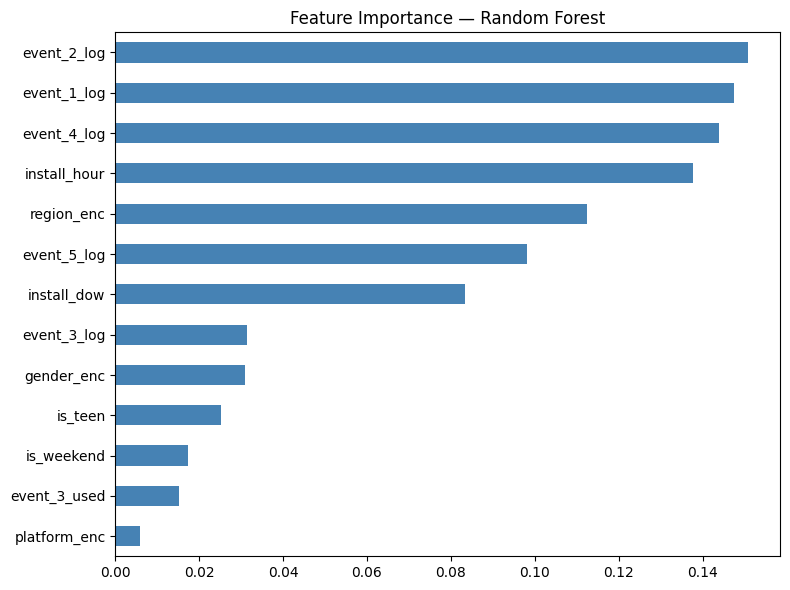

In [5]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

**Conclusiones del Random Forest:**

**Performance:** ROC-AUC de 0.7731 — prácticamente igual al baseline de Logistic Regression (0.7749). Con parámetros default no hay mejora significativa.

**Feature importance — ranking más confiable que LR:**
- `event_2_log` y `event_1_log` al tope, consistente con el EDA donde mostraban la mayor diferencia entre grupos.
- `install_hour` aparece como 4to más importante — la LR lo ignoraba por multicolinealidad.
- `region_enc` sube al 5to puesto — tampoco lo capturaba la LR.
- `is_weekend` cae al fondo — en la LR era el coeficiente más fuerte, probablemente inflado por correlación con `install_dow`.
- `platform_enc` cae al último — su efecto queda capturado por otras features.

**Conclusión:** el RF resuelve el problema de multicolinealidad de la LR y da un ranking de importancia más creíble. Sin embargo, no mejora el AUC con estos parámetros. XGBoost, con su mecanismo de boosting, debería capturar mejor las interacciones y mejorar la performance.